In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
raw_data = pd.read_csv("dataset/diabetes.csv")
raw_data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
raw_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
raw_data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


# EDA

In [12]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
raw_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
raw_data.shape

(768, 9)

The diabetes data set consists of 768 entries, with 9 features.



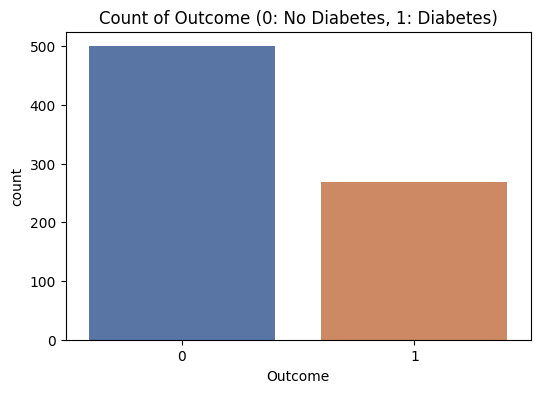

In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=raw_data, hue='Outcome', palette='deep', legend=False, label='Count')
plt.title('Count of Outcome (0: No Diabetes, 1: Diabetes)')
plt.show()

“Outcome” is the feature we are going to predict, 0 means No diabetes, 1 means diabetes. Of these 768 data points, 500 are labeled as 0 and 268 as 1.

In [134]:
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

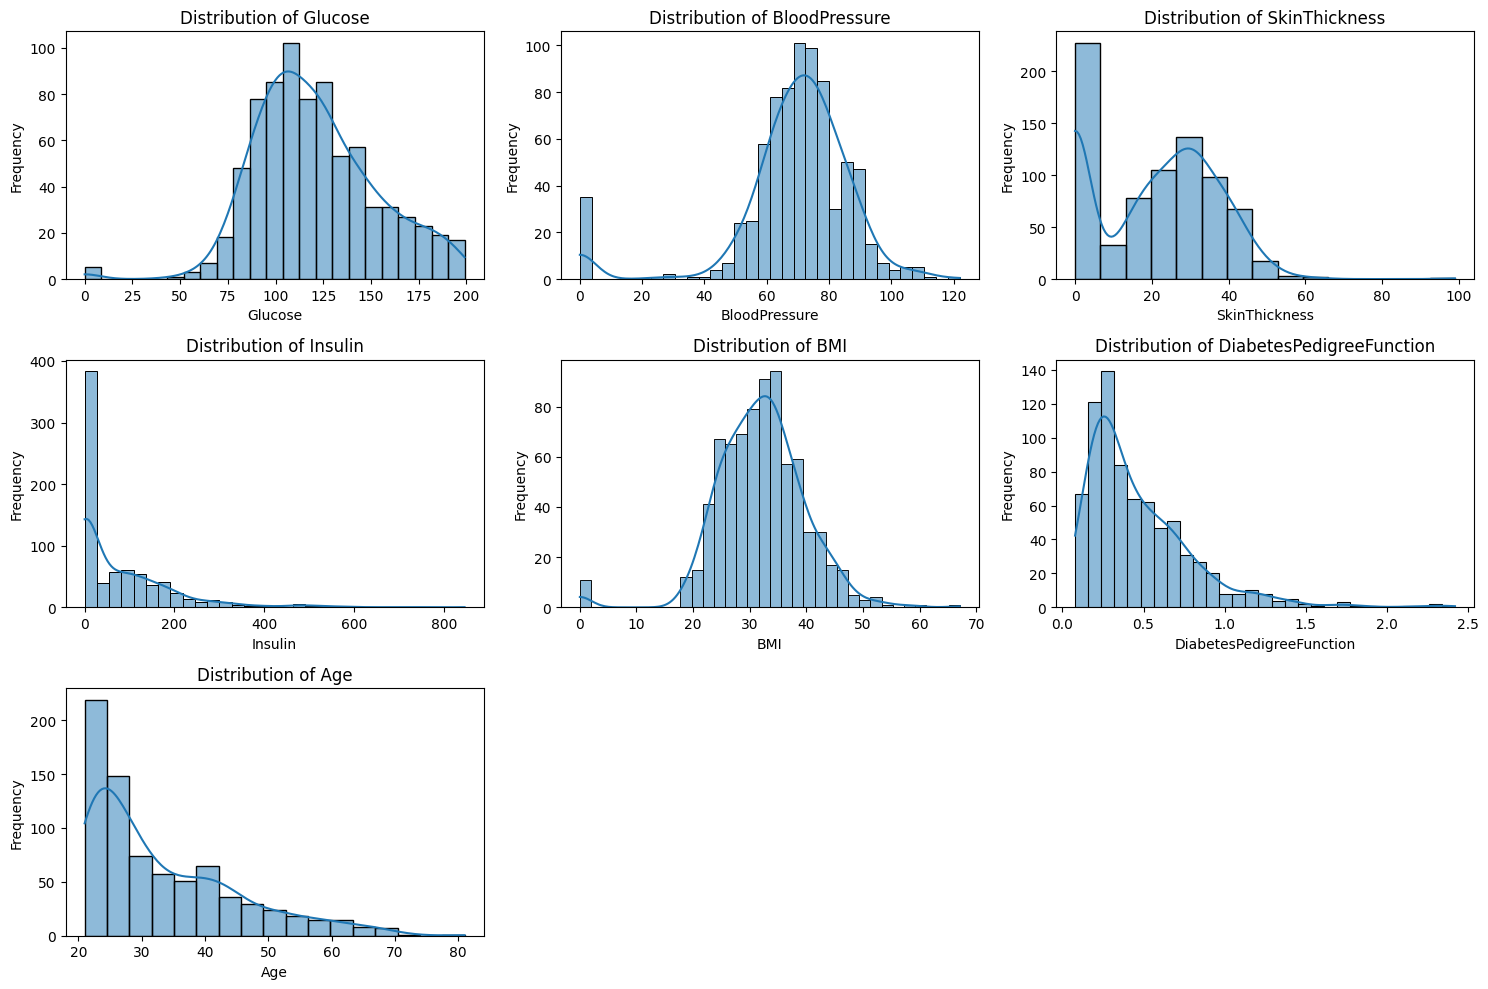

In [54]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(raw_data[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [58]:
skewness = raw_data[features].skew()
display(skewness)

,0
Glucose,0.173754
BloodPressure,-1.843608
SkinThickness,0.109372
Insulin,2.272251
BMI,-0.428982
DiabetesPedigreeFunction,1.919911
Age,1.129597


The skewness values indicate how asymmetrical the distributions of the features are.

*   A skewness value close to 0 suggests a symmetric distribution.
*   Positive skewness (right-skewed) means the tail on the right side is longer, and the majority of data points are concentrated on the left.
*   Negative skewness (left-skewed) means the tail on the left side is longer, and the majority of data points are concentrated on the right.

I can see that several features, such as `Insulin`, `DiabetesPedigreeFunction`, and `Age`, exhibit significant positive skewness, indicating a longer tail towards higher values. `BloodPressure` and `BMI` also show some positive skewness.

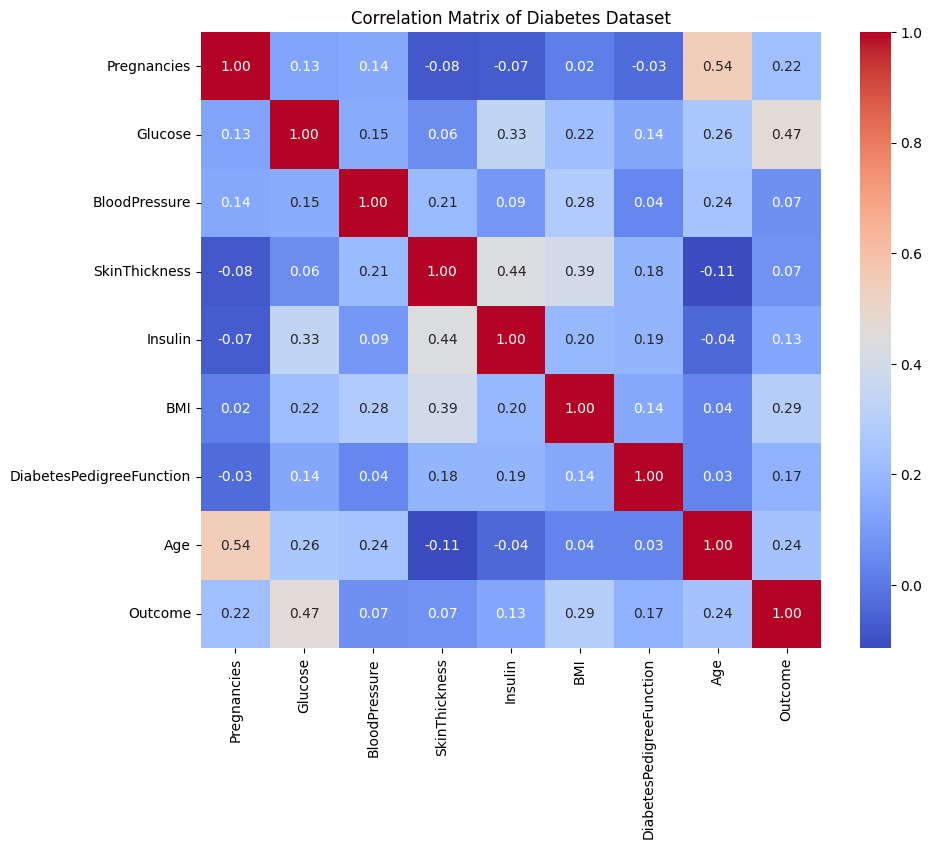

In [57]:
plt.figure(figsize=(10, 8))
sns.heatmap(raw_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Diabetes Dataset')
plt.show()

The correlations between the independent features. I don't see any pairs of independent features that have an extremely high correlation (e.g., above 0.9 or 0.95) in this dataset.

The highest correlations between features like 'SkinThickness' and 'Insulin' (0.44), or 'BMI' and 'SkinThickness' (0.39), are moderate but not high enough to suggest they are redundant or 'telling the same story' to the extent of needing to remove one.

# Modeling


In [168]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn import neighbors

### KNN

In [60]:
X = raw_data.drop('Outcome', axis=1)
y = raw_data['Outcome']

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=65)

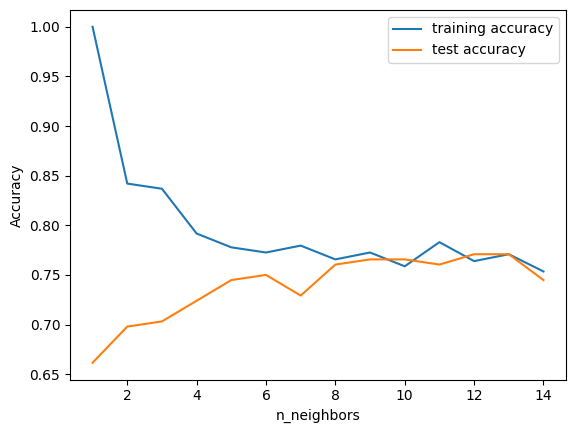

In [155]:
training_acc = []
test_acc = []

neighbors_settings = range(1, 15)
for n_neighbors in neighbors_settings:
  knn = KNeighborsClassifier(n_neighbors=n_neighbors)
  knn.fit(X_train, y_train)

  # Save the progress
  training_acc.append(knn.score(X_train, y_train))
  test_acc.append(knn.score(X_test, y_test))

plt.plot(neighbors_settings, training_acc, label="training accuracy")
plt.plot(neighbors_settings, test_acc, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.show()

Through iterative testing, $n=9$ & $n=13$ was identified as the ideal number of neighbors. At $n=13$, both training and testing accuracy reached 0.77, indicating that the model has successfully generalized.

In [107]:
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train, y_train)
print("Accuracy of KNN Classifier on training set: {:.2f}%".format(knn.score(X_train, y_train)*100))
print("Accuracy of KNN Classifier on test set: {:.2f}".format(knn.score(X_test, y_test)*100))

Accuracy of KNN Classifier on training set: 77.08%
Accuracy of KNN Classifier on test set: 77.08


### Decision Tree

In [125]:
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print("Accuracy of Decision Tree Classifier on training set: {:.2f}%".format(tree.score(X_train, y_train)*100))
print("Accuracy of Decision Tree Classifier on test set: {:.2f}%".format(tree.score(X_test, y_test)))

Accuracy of Decision Tree Classifier on training set: 100.00%
Accuracy of Decision Tree Classifier on test set: 0.71%


The accuracy on the training set with Decision Tree Classifier is 100%, while the test set accuracy is much worse. This is an indicative that the tree is overfitting and not generalizing well to new data. Therefore, we need to apply pre-pruning to the tree.

In [129]:
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 0.778
Accuracy on test set: 0.760


Here, setting **max_depth=3**, limiting the depth of the tree decreases overfitting. This leads to a lower accuracy on the training set, but an improvement on the test set

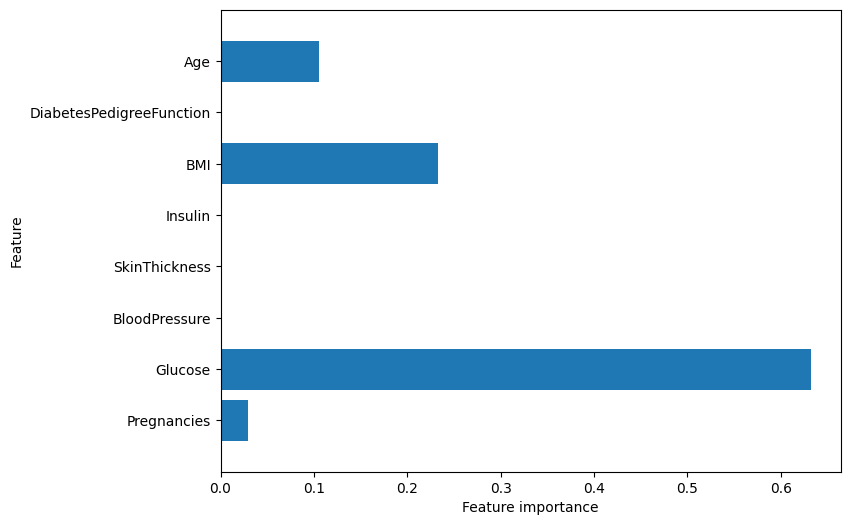

In [143]:
def plot_feature_importances_diabetes(model):
    plt.figure(figsize=(8,6))
    diabetes_features = X.columns
    n_features = len(diabetes_features)
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), diabetes_features)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)
plot_feature_importances_diabetes(tree)

Feature importance shows how important each feature is for the decision a decision tree classifier makes. It is a number between 0 and 1 for each feature (0 not useful & 1 useful).

Here, it clearly shows `Glucose` feature is used the most to predict diabetes.

### Multi-Layer Perceptron

In [156]:
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)
print("Accuracy on training set: {:.2f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.74
Accuracy on test set: 0.71


The accuracy of the Multilayer perceptrons (MLP) is not as good as the other models at all, this is likely due to scaling of the data.

In [160]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [163]:
mlp = MLPClassifier(random_state=0)
mlp.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Accuracy on training set: 0.821
Accuracy on test set: 0.745


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [169]:
mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Accuracy on training set: 0.811
Accuracy on test set: 0.771


In [167]:
# Predictions for KNN
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

# Predictions for Decision Tree
y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

# Predictions for MLP (Scaled)
y_pred_mlp = mlp.predict(X_test_scaled)
y_proba_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

model_comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'MLP (Scaled)'],
    'Training Accuracy': [
        knn.score(X_train, y_train),
        tree.score(X_train, y_train),
        mlp.score(X_train_scaled, y_train)
    ],
    'Test Accuracy': [
        knn.score(X_test, y_test),
        tree.score(X_test, y_test),
        mlp.score(X_test_scaled, y_test)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_mlp)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_mlp)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_knn),
        roc_auc_score(y_test, y_proba_tree),
        roc_auc_score(y_test, y_proba_mlp)
    ]
})

print(model_comparison.round(3))

           Model  Training Accuracy  Test Accuracy  Recall  F1-Score  ROC-AUC
0            KNN              0.753          0.745   0.463     0.559    0.792
1  Decision Tree              0.778          0.760   0.597     0.635    0.795
2   MLP (Scaled)              0.821          0.745   0.582     0.614    0.851


The MLP (Scaled) model performs best overall.

*   It has the highest ROC-AUC (0.851), meaning it’s the most reliable at distinguishing diabetic vs. non-diabetic cases across thresholds.
*   Its recall (0.582) is nearly as good as the Decision Tree (0.597), but the superior ROC-AUC makes it more robust.

In medical screening, recall is critical, but ROC-AUC ensures the model isn’t just tuned to one threshold — it’s consistently strong across decision boundaries. The result is good, but we are not able to increase the test accuracy further. Therefore, our best model so far is default MLP model after scaling.